# b)

In [1]:
import qiskit
import random
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

backend = AerSimulator(method="statevector")

plt.rcParams.update({"font.family": "Times New Roman", "mathtext.fontset": "cm"})

In [2]:
def prepare_states(N, x: str):
    qcircuit = qiskit.QuantumCircuit(N + 1)
    for i, xi in enumerate(x):
        if xi == "1": qcircuit.x(i)
    qcircuit.barrier()
    return qcircuit

def measure_N(N):
    qcircuit = qiskit.QuantumCircuit(N + 1, 1)
    qcircuit.measure(N, 0)
    return qcircuit

def DJ_init(N):
    qcircuit = qiskit.QuantumCircuit(N + 1)
    
    qcircuit.x(N)
    for i in range(N + 1): qcircuit.h(i)
    qcircuit.barrier()
    return qcircuit

def DJ_finish(N):
    qcircuit = qiskit.QuantumCircuit(N + 1, N)
    for i in range(N): qcircuit.h(i)
    qcircuit.measure(range(N), range(N))
    return qcircuit

def projector(N, j):
    qcircuit = qiskit.QuantumCircuit(N + 1)
    qcircuit.cx(j, N)
    qcircuit.barrier()
    return qcircuit

def self_dot_product(N):
    qcircuit = qiskit.QuantumCircuit(N + 1)
    for i in range(N): qcircuit.cx(i, N)
    qcircuit.barrier()
    return qcircuit

def CNOT_function(N, k, i):
    qcircuit = qiskit.QuantumCircuit(N + 1)
    qcircuit.cx(k, N)
    qcircuit.cx(i, N)
    qcircuit.barrier()
    return qcircuit

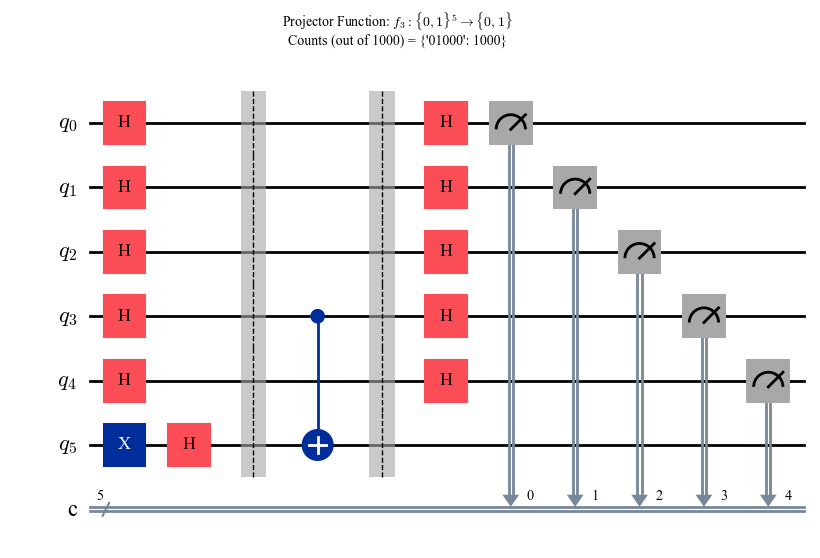

In [3]:
a, b = 2, 10
N = random.choice(range(a, b))
j = random.choice(range(N))
DJ = DJ_init(N).compose(projector(N, j).compose(DJ_finish(N)))
fig = plt.figure(DJ.draw(output='mpl'))

# Simulationion function
shots = 1000
counts = backend.run(DJ, shots=shots).result().get_counts()
func_name = f"Projector Function: $f_{j}:\\{{0, 1\\}}^{N}"
func_name += "\\rightarrow \\{{0, 1\\}}$"
fig.suptitle(f"{func_name}\nCounts (out of {shots}) = {counts}",
             fontsize=10)
plt.show()

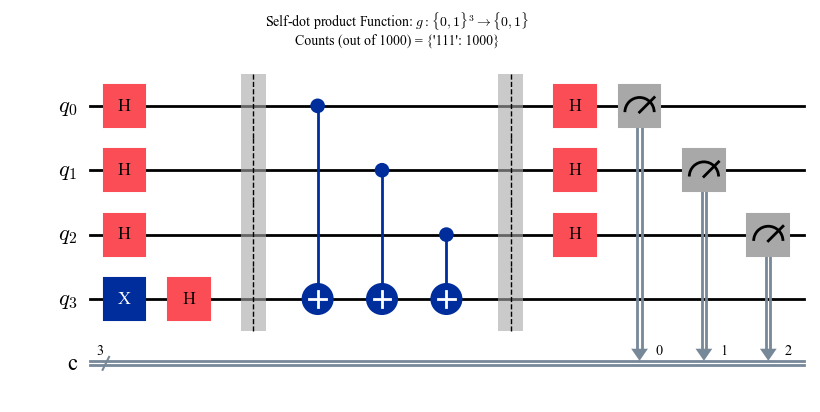

In [4]:
a, b = 2, 10
N = random.choice(range(a, b))
j = random.choice(range(N))
DJ = DJ_init(N).compose(self_dot_product(N).compose(DJ_finish(N)))
fig = plt.figure(DJ.draw(output='mpl'))

# Simulation
shots = 1000
counts = backend.run(DJ, shots=shots).result().get_counts()
func_name = f"Self-dot product Function: $g:\\{{0, 1\\}}^{N}$"
func_name += "$\\rightarrow \\{{0, 1\\}}$"
fig.suptitle(f"{func_name}\nCounts (out of {shots}) = {counts}",
             fontsize=10)
plt.show()

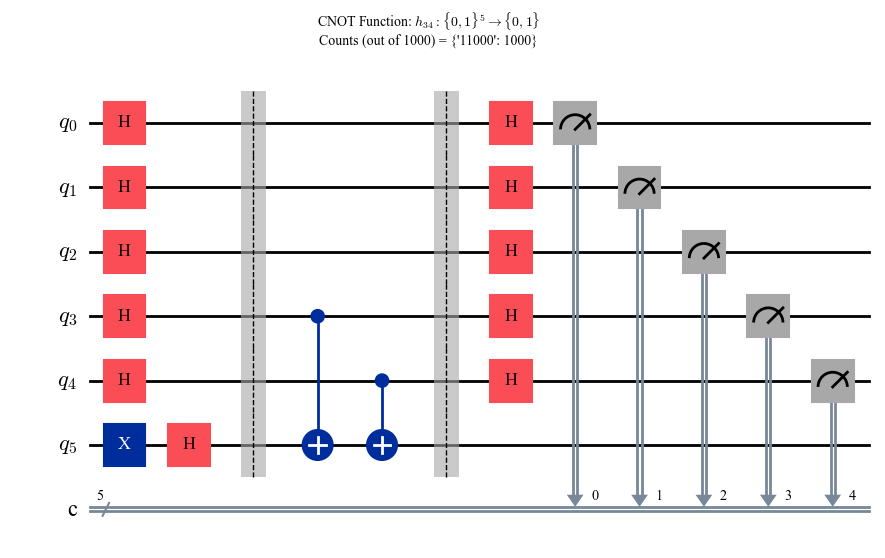

In [5]:
a, b = 2, 10
N = random.choice(range(a, b))
k = random.choice(range(N))
i = random.choice(range(N))
DJ = DJ_init(N).compose(CNOT_function(N, k, i).compose(DJ_finish(N)))
fig = plt.figure(DJ.draw(output='mpl'))

# Simulation
shots = 1000
counts = backend.run(DJ, shots=shots).result().get_counts()
func_name = f"CNOT Function: $h_{{{k}{i}}}:\\{{0, 1\\}}^{N}"
func_name += "\\rightarrow \\{{0, 1\\}}$"
fig.suptitle(f"{func_name}\nCounts (out of {shots}) = {counts}",
             fontsize=10)
plt.show()

# 2. Pennylane

(a) *Crea un circuito sencillo en pennylane y busca distintos tipos de draw. Y me expliques cual es
tu favorito y por qué.*

In [6]:
import pennylane as qml
import matplotlib.patches as patches
import numpy as np

In [7]:
N = 3
device = qml.device('default.qubit', N)

@qml.qnode(device)
def circuit(theta, phi):
    qml.X(N - 1)
    for i in range(N): qml.H(i)
    qml.Barrier()
    
    qml.SWAP(wires=[0, 2])
    qml.CRY(theta, wires=[0, 1])
    qml.RZ(phi, wires=2)
    qml.Barrier()
    
    for i in range(N - 1): qml.H(i)
    
    expvals = []
    for i in range(N - 1):
        expvals.append(qml.expval(qml.PauliZ(i)))
    return expvals

theta, phi = np.pi/2, np.pi

In [8]:
print(qml.draw(circuit)(theta, phi))

0: ──H─────||─╭SWAP─╭●─────────||──H─┤  <Z>
1: ──H─────||─│─────╰RY(1.57)──||──H─┤  <Z>
2: ──X──H──||─╰SWAP──RZ(3.14)──||────┤     


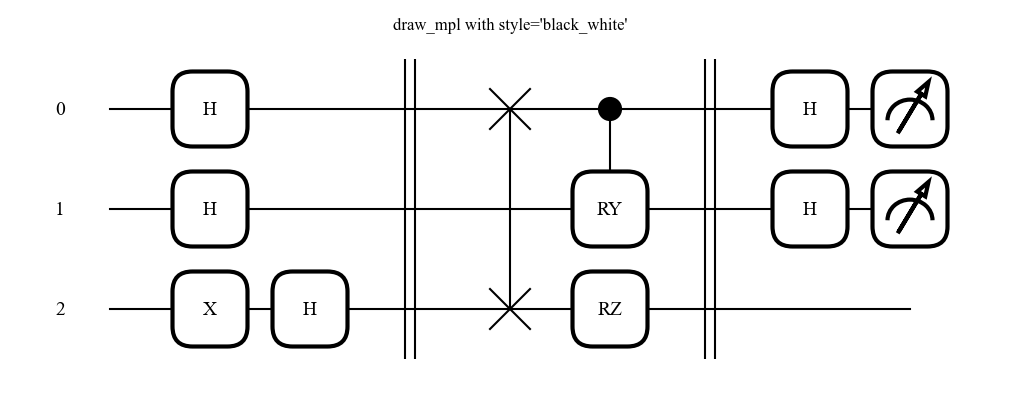

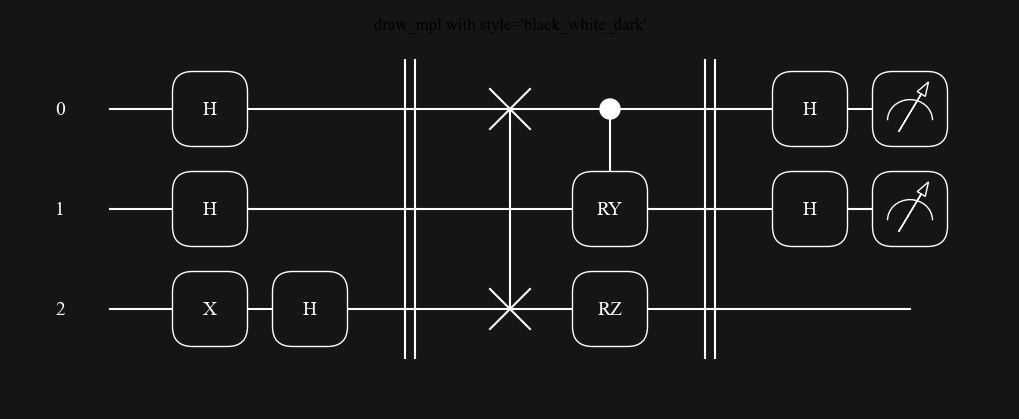

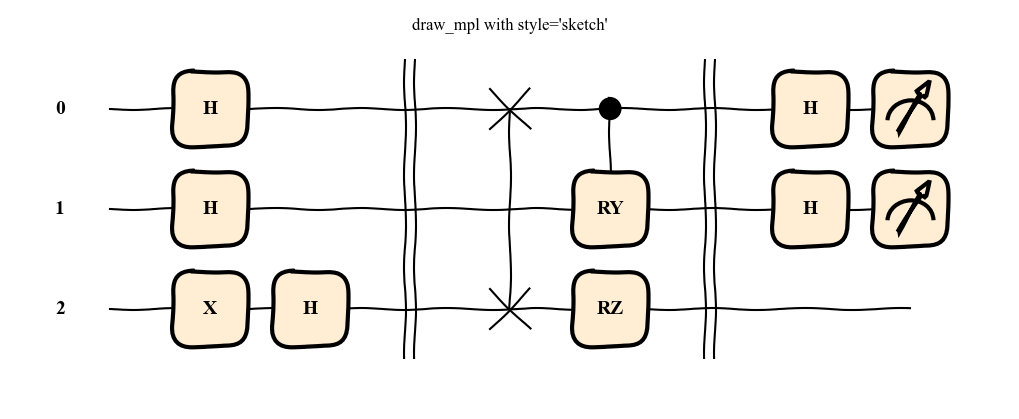

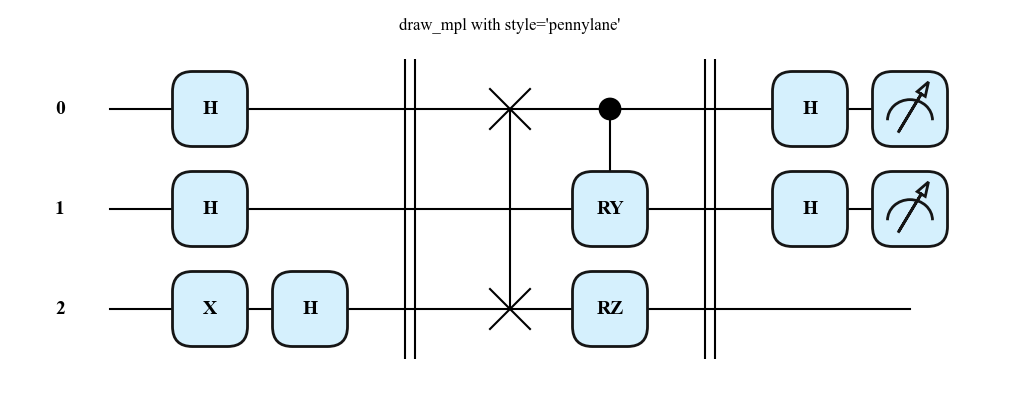

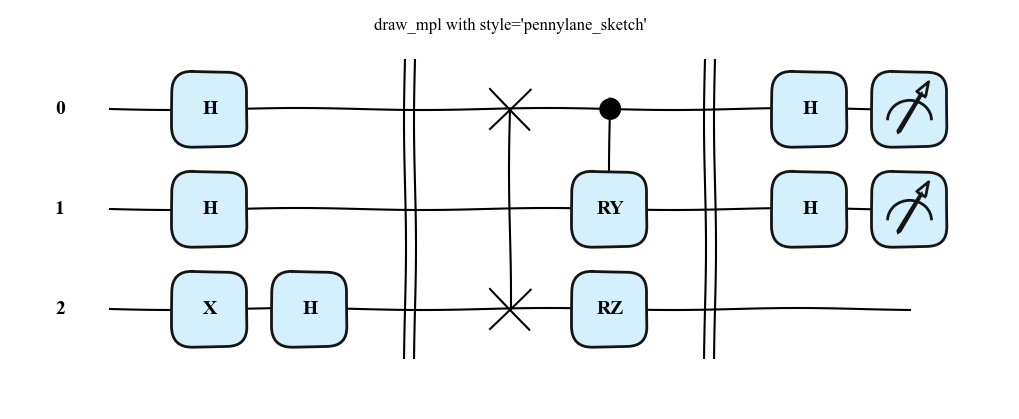

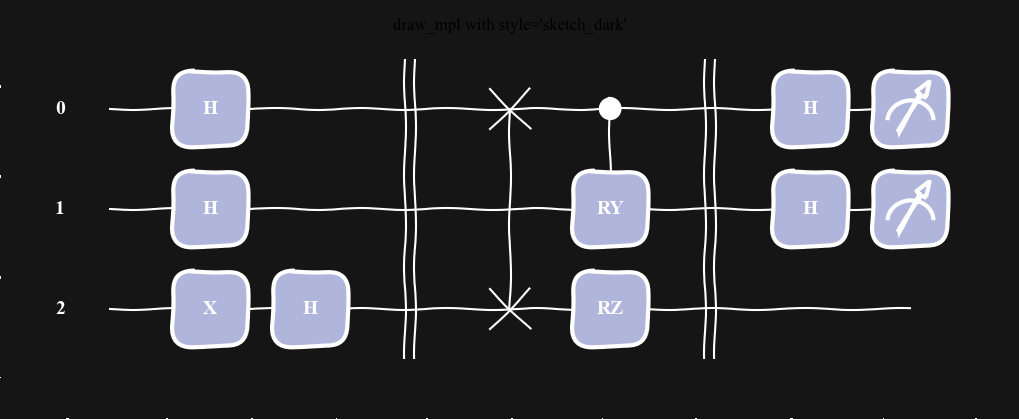

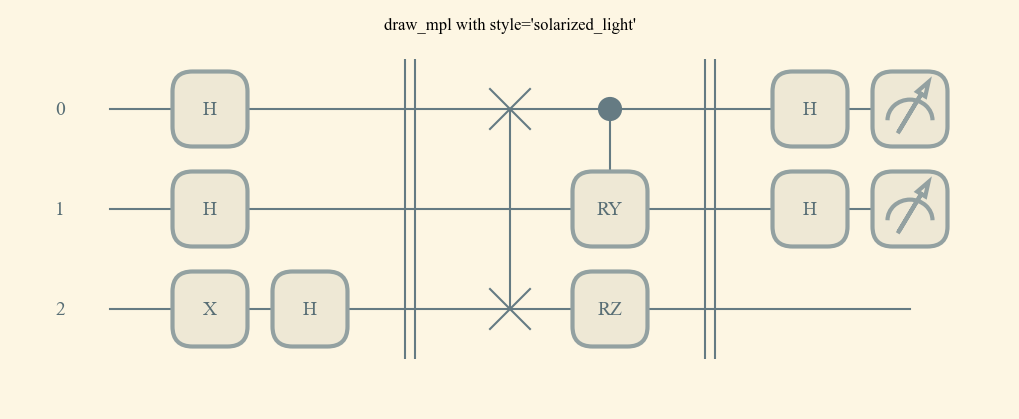

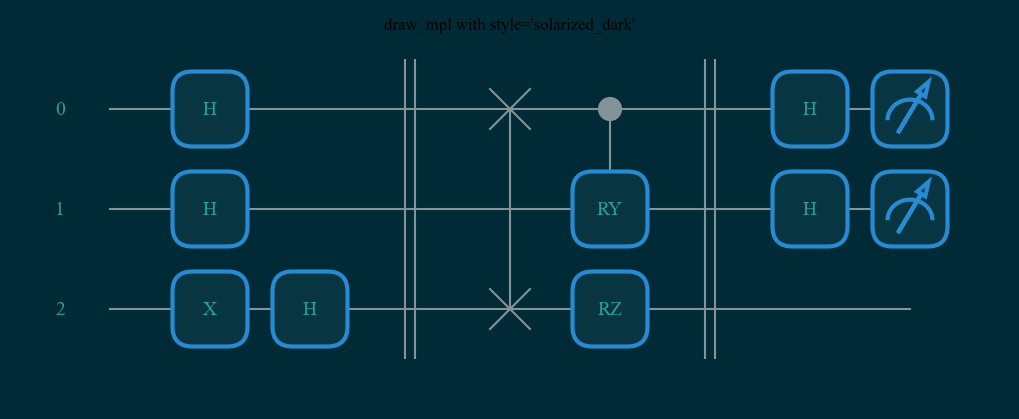

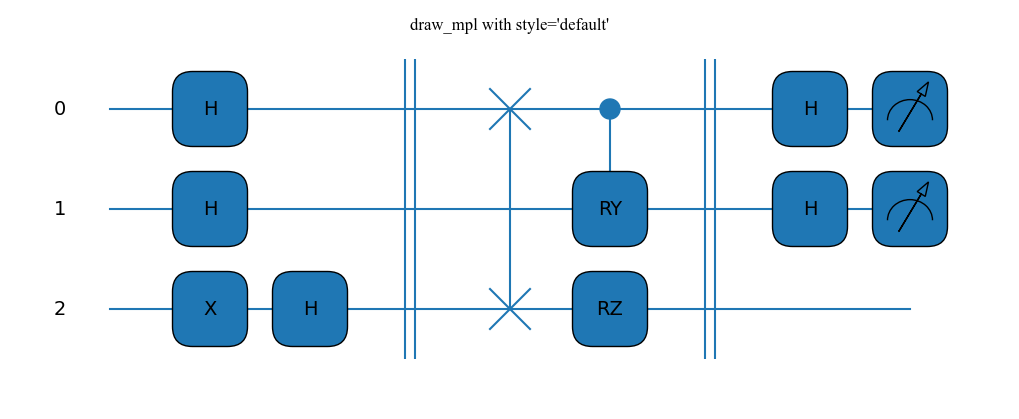

In [9]:
styles = ('black_white', 'black_white_dark', 'sketch', 'pennylane',
          'pennylane_sketch', 'sketch_dark', 'solarized_light',
          'solarized_dark', 'default')
for style in styles:
    fig, ax = qml.draw_mpl(circuit, style=style)(theta, phi)
    fig.suptitle(f"draw_mpl with {style=}")
    
    fig.canvas.draw()

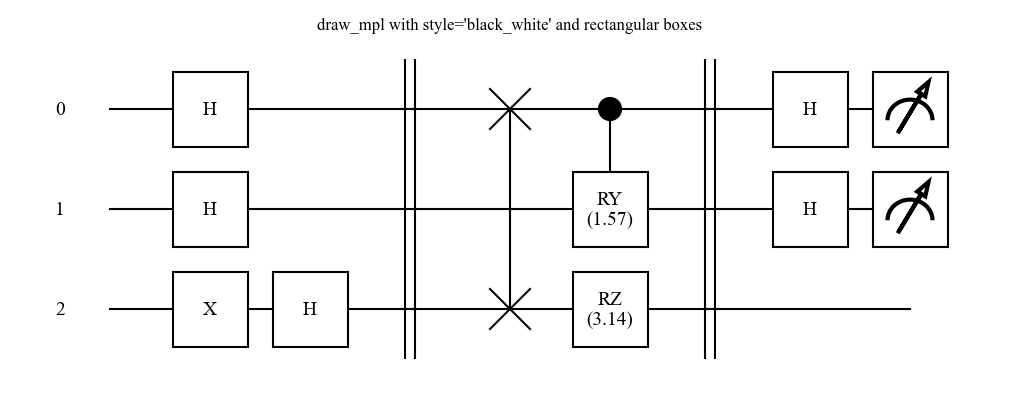

In [10]:
fig, ax = qml.draw_mpl(circuit, style='black_white',
                       decimals=2)(theta, phi)
fig.suptitle("draw_mpl with style='black_white' and rectangular boxes")

for p in ax.patches:
    if isinstance(p, patches.FancyBboxPatch):
        p.set_boxstyle("square,pad=0.2")
        p.set_linewidth(1.5)

fig.canvas.draw()

Prefiero `draw_mpl` sobre `draw`, pues es más claro y puede reproducir mostrar el valor de los parámetros como `draw` si uso `decimals=k`. También prefiero el estilo de la última celda que es más parecido a *qiskit*.

# c)
*Repitan el desarrollo matemático que hicimos para RX en las matrices RY y RZ, y luego generen el
circuito en Pennylane, de return coloquen el valor esperado de de la matriz de Paulli Z, grafiquenlo
en Matplotlib y argumenten si lo que graficaron se corresponde a lo que el circuito que predijeron
iba a dar.*

In [11]:
import pennylane as qml
import matplotlib.cm as cm
import numpy as np

colors = cm.gray

In [12]:
device = qml.device('default.qubit', wires=1)

@qml.qnode(device)
def RZ(theta):
    qml.RZ(theta, wires=0)
    
    return qml.expval(qml.Z(wires=0))

@qml.qnode(device)
def RY(theta):
    qml.RY(theta, wires=0)
    
    return qml.expval(qml.Z(wires=0))

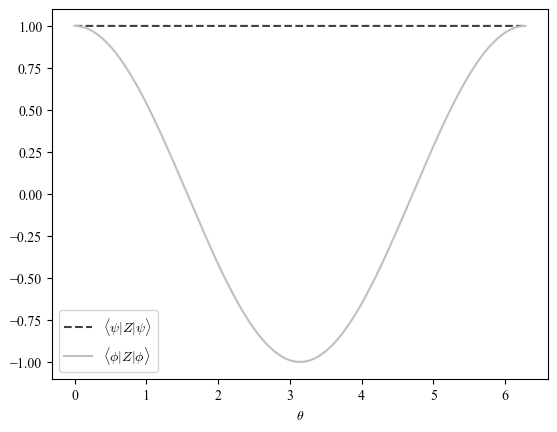

In [13]:
theta = np.linspace(0, 2*np.pi, 10**4)
fig, ax = plt.subplots()
ax.set(xlabel="$\\theta$", ylabel="")
ax.plot(theta, RZ(theta), label=r"$\langle \psi | Z | \psi \rangle$",
        color=colors(0.25), ls='--')
ax.plot(theta, RY(theta), label=r"$\langle \phi | Z | \phi \rangle$",
        color=colors(0.75))
plt.legend()
plt.show()